
## What Are Embeddings?
Embedding is a way to translate words into a language that computers understand - numbers!

## Trying to visualise it

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

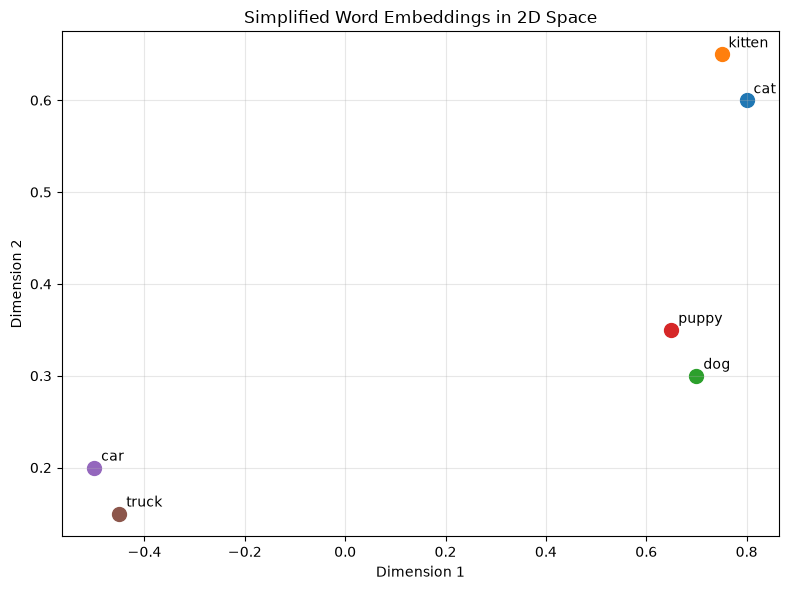

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Measuring Similarity

In [ ]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1) # magnitude of a
    norm_b=np.linalg.norm(vec2) # magnitude of a
    return dot_product/(norm_a * norm_b)


In [5]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192183


In [6]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.4371858854891681)

### Trying to create Embeddings

In [7]:
### Huggingface And OpenAI Models

from langchain_huggingface import HuggingFaceEmbeddings

## Initializing a simple Embedding model(without API Key need!)
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2" ## From huggingface website (This is a sentence-transformers model: It maps sentences & 
                                                        # paragraphs to a 384 dimensional dense vector space and can be used for tasks like 
                                                        # clustering or semantic search.)
)
embeddings

e:\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6628.11it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [8]:
## creating my first embeddings
text="Hello, I am learning about embeddings!"

embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)

Text: Hello, I am learning about embeddings!
Embedding length : 384
[-0.0181632898747921, -0.09955168515443802, 0.01381611730903387, -0.008125905878841877, 0.014152229763567448, 0.06406489759683609, -0.006253313738852739, -0.0030179021414369345, 0.025287268683314323, -0.02019866183400154, 0.024329721927642822, 0.07435052841901779, 0.05117719620466232, 0.022038480266928673, -0.058306191116571426, 0.015268274582922459, 0.02358439192175865, 0.09455393999814987, -0.06508848071098328, 0.013296668417751789, -0.020497575402259827, -0.05690854415297508, 0.030303336679935455, -0.08365611732006073, 0.026596346870064735, -0.015231448225677013, -0.04361536353826523, 0.053983986377716064, 0.09025715291500092, -0.08893878012895584, 0.039644598960876465, -0.0088350223377347, -0.030343789607286453, 0.07425570487976074, -0.0540991872549057, 0.11108000576496124, 0.0368998683989048, -0.008959777653217316, -0.06140237674117088, -0.0031433971598744392, 0.02195824310183525, 0.04220820218324661, -0.028937844

In [9]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.13040179014205933, -0.011870082467794418, -0.028117064386606216, 0.05123867094516754, -0.055974461138248444, 0.030191533267498016, 0.030161313712596893, 0.02469841204583645, -0.018370570614933968, 0.05876680091023445, -0.024953201413154602, 0.06015423685312271, 0.03983177989721298, 0.0332304984331131, -0.061311401426792145, -0.04937313497066498, -0.054863546043634415, -0.040076106786727905, 0.05642914026975632, 0.039156556129455566, -0.03473712503910065, -0.013247662223875523, 0.0319662019610405, -0.06349921971559525, -0.06017858162522316, 0.07823453098535538, -0.028303852304816246, -0.047442883253097534, 0.040359269827604294, -0.006630906835198402, -0.066740982234478, -0.0041913059540092945, -0.02531164512038231, 0.05334165692329407, 0.017428087070584297, -0.09792359918355942, 0.006061331368982792, -0.06524167209863663, 0.04557260125875473, 0.023641841486096382, 0.07658485323190689, -0.010264329612255096, -0.004076807759702206, -0.06232282146811485, 0.03370523452758789, 0.018661146

In [13]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  Embedding size: {info['size']} dimensions")
    print(f"  Description: {info['description']}")
    print(f"  Use case: {info['use_case']}\n")
    print("-" * 50)

Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  Embedding size: 384 dimensions
  Description: Fast and efficient, good quality
  Use case: General purpose, real-time applications

--------------------------------------------------
Model: sentence-transformers/all-mpnet-base-v2
  Embedding size: 768 dimensions
  Description: Best quality, slower than MiniLM
  Use case: When quality matters more than speed

--------------------------------------------------
Model: sentence-transformers/all-MiniLM-L12-v2
  Embedding size: 384 dimensions
  Description: Slightly better than L6, bit slower
  Use case: Good balance of speed and quality

--------------------------------------------------
Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  Embedding size: 384 dimensions
  Description: Optimized for question-answering
  Use case: Q&A systems, semantic search

--------------------------------------------------
Model: sentence-transformers/paraphrase-mul